# Kolmogorov Flow — Sanity Check

This notebook:
1. Loads a generated `kolmogorov_data.npz` via `KolmogorovDataset`
2. Visualizes velocity field snapshots and observation grid locations
3. Verifies that `EnsembleScoreFilter` runs without errors on the dataset

## Prerequisites

Generate a dataset first (from the repo root):
```bash
python generate.py --system kolmogorov \
    --num-trajectories 200 \
    --obs-grid-size 150 \
    --output-dir datasets/
```

For the sparse (paper) observation grid:
```bash
python generate.py --system kolmogorov \
    --num-trajectories 200 \
    --obs-grid-size 10 \
    --output-dir datasets/
```

JAX and jax-cfd are only needed for generation, not for this notebook.

In [1]:
import sys
import os
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath('.')), ''))

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path

from data import KolmogorovConfig, KolmogorovSystem, KolmogorovDataset
from models.ensf import EnsembleScoreFilter

## Configuration

Point `NPZ_PATH` at a generated dataset.

In [2]:
# Path to the generated .npz file — adjust as needed
NPZ_PATH = Path("/data/da_outputs/datasets/kolmogorov_n200_len200_dt0p0400_grid150_obs150x150_obsnoise0p000/kolmogorov_data.npz")

# Use the same obs_grid_size that the dataset was generated with
# (150 = fully observed, 10 = paper's sparse 100-point grid)
OBS_GRID_SIZE = 150

config = KolmogorovConfig(
    obs_grid_size=OBS_GRID_SIZE,
    obs_noise_std=0.0,
)
system = KolmogorovSystem(config)

print(f"State dim : {system.state_dim:,}  ({config.grid_size}×{config.grid_size}×2)")
print(f"Obs dim   : {system.obs_dim:,}  ({config.obs_grid_size}×{config.obs_grid_size}×2)")

State dim : 45,000  (150×150×2)
Obs dim   : 45,000  (150×150×2)


In [3]:
train_ds = KolmogorovDataset(NPZ_PATH, config, system, split="train", mode="train")
test_ds  = KolmogorovDataset(NPZ_PATH, config, system, split="test",  mode="inference")

print(f"Train trajectories : {len(train_ds)}")
print(f"Test  items        : {len(test_ds)}  (trajectories × timesteps)")

sample = train_ds[0]
print(f"\nTrain item keys : {list(sample.keys())}")
print(f"  x shape        : {sample['x'].shape}   (Nt, state_dim)")
print(f"  y shape        : {sample['y'].shape}   (Nt_obs, obs_dim)")
print(f"  Reynolds number: {sample['u'].item():.1f}")

Train trajectories : 120
Test  items        : 7960  (trajectories × timesteps)

Train item keys : ['trajectory_idx', 'x', 'y', 'u', 'dt', 'obs_mask']
  x shape        : torch.Size([200, 45000])   (Nt, state_dim)
  y shape        : torch.Size([40, 45000])   (Nt_obs, obs_dim)
  Reynolds number: 874.5


## Visualise Velocity Field Snapshots

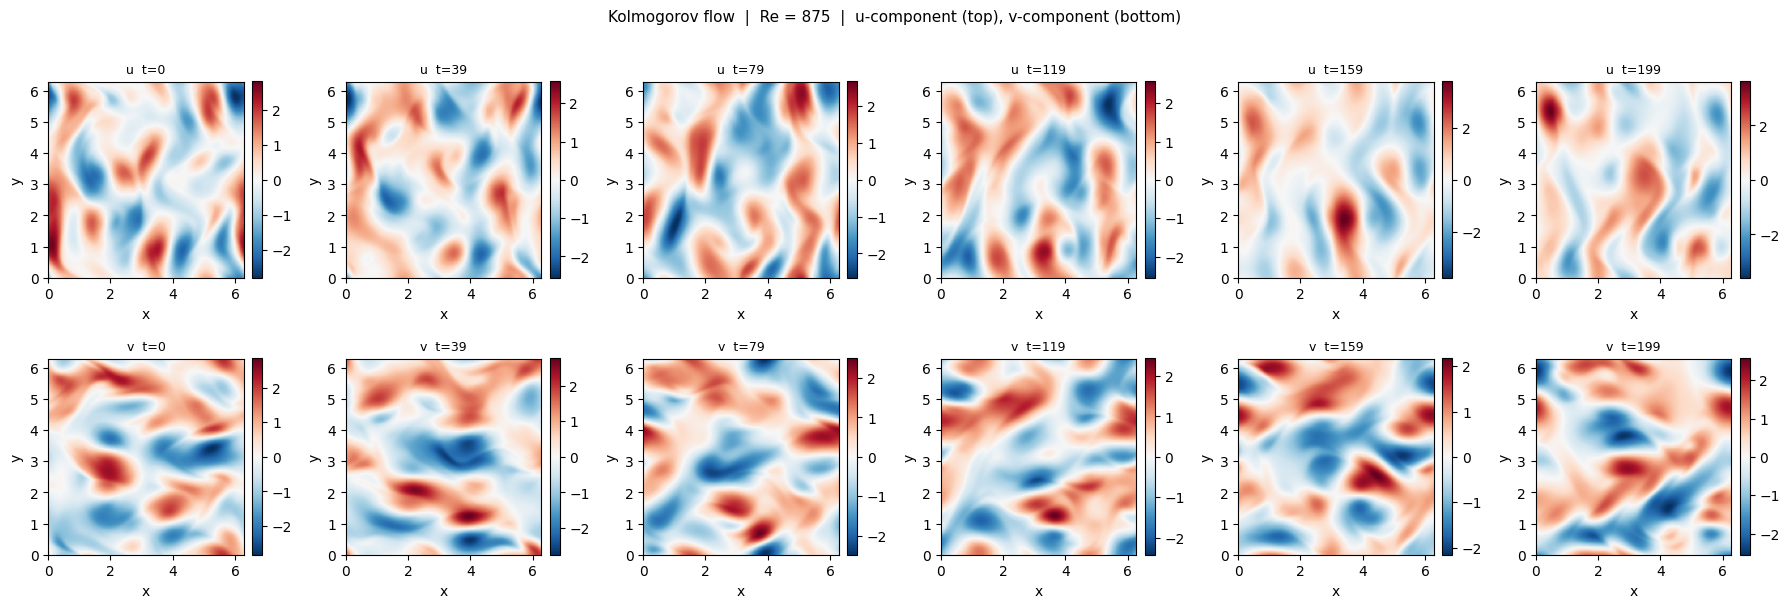

In [4]:
def plot_field(ax, field_2d, title, cmap="RdBu_r", vmax=None):
    """Plot a 2D velocity component as a colour map."""
    v = vmax or float(np.abs(field_2d).max())
    im = ax.imshow(field_2d, origin="lower", cmap=cmap,
                   vmin=-v, vmax=v, extent=[0, 2*np.pi, 0, 2*np.pi])
    ax.set_title(title, fontsize=9)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    return im


# Show 6 evenly-spaced snapshots from the first training trajectory
traj_item = train_ds[0]
H = W = config.grid_size
x_traj = traj_item["x"].numpy()           # [Nt, 2*H*W]
re_val = traj_item["u"].item()
Nt = x_traj.shape[0]

snap_times = np.linspace(0, Nt - 1, 6, dtype=int)

fig, axes = plt.subplots(2, 6, figsize=(18, 6))
fig.suptitle(f"Kolmogorov flow  |  Re = {re_val:.0f}  |  u-component (top), v-component (bottom)",
             fontsize=11, y=1.01)

for col, t in enumerate(snap_times):
    field = x_traj[t].reshape(2, H, W)    # (2, H, W)
    plot_field(axes[0, col], field[0], f"u  t={t}")
    plot_field(axes[1, col], field[1], f"v  t={t}")

plt.tight_layout()
plt.show()

## Visualise Observation Grid

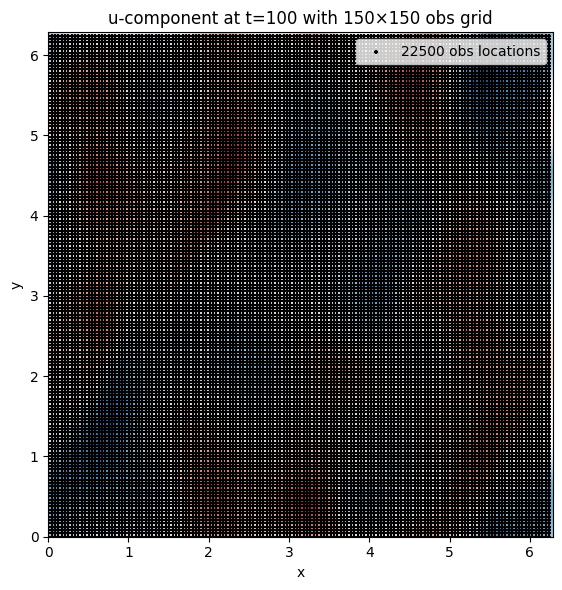

Total observation points : 22500 spatial × 2 components = 45000 values


In [5]:
# Recover the spatial locations of the observation grid points
stride = config.grid_size // config.obs_grid_size
obs_xs = np.arange(0, config.grid_size, stride)   # x-coordinates (pixels)
obs_ys = np.arange(0, config.grid_size, stride)   # y-coordinates (pixels)
gx, gy = np.meshgrid(obs_xs, obs_ys)
# Convert pixel indices to physical coordinates [0, 2π]
scale = 2 * np.pi / config.grid_size
obs_x_phys = (gx * scale).ravel()
obs_y_phys = (gy * scale).ravel()

fig, ax = plt.subplots(figsize=(6, 6))
t_show = Nt // 2
field = x_traj[t_show].reshape(2, H, W)
v_max = float(np.abs(field[0]).max())
ax.imshow(field[0], origin="lower", cmap="RdBu_r",
          vmin=-v_max, vmax=v_max,
          extent=[0, 2*np.pi, 0, 2*np.pi], alpha=0.85)
ax.scatter(obs_x_phys, obs_y_phys, s=12, c="k", marker="+",
           label=f"{len(obs_x_phys)} obs locations")
ax.set_title(f"u-component at t={t_show} with {config.obs_grid_size}×{config.obs_grid_size} obs grid")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

print(f"Total observation points : {len(obs_x_phys)} spatial × 2 components = {system.obs_dim} values")

## EnsembleScoreFilter Interface Check

Run EnSF on a single test trajectory over all 40 assimilation steps and record RMSE.

> **Note:** With the full 150×150 state (45,000 dims) this is slow on CPU — the purpose
> is only to verify that the data shapes are correct and the filter runs without errors.
> For practical experiments the LDNet latent representation (to be added later) will reduce
> the state to ~9 dimensions.

In [ ]:
# Updated EnSF rollout for Kolmogorov with Reynolds metadata.
from tqdm.auto import tqdm

rmse_list  = []
times_list = []

for step_item in tqdm(traj_steps, desc="EnSF steps (with Re)"):
    x_prev = step_item["x_prev"].unsqueeze(0).to(DEVICE)
    x_curr = step_item["x_curr"].unsqueeze(0).to(DEVICE)
    t_idx  = step_item["time_idx"].item()

    has_obs = step_item["has_observation"].item()
    y_curr = step_item["y_curr"].unsqueeze(0).to(DEVICE) if has_obs else None
    reynolds = step_item["reynolds"].unsqueeze(0).to(DEVICE)

    results = ensf.step(
        x_prev=x_prev,
        x_curr=x_curr,
        y_curr=y_curr,
        dt=config.dt,
        trajectory_idxs=torch.LongTensor([test_traj_idx]),
        time_idxs=torch.LongTensor([t_idx]),
        static_params={"reynolds": reynolds},
    )
    rmse_list.append(results[0]["rmse"])
    times_list.append(t_idx)

print(f"Run complete. Mean RMSE = {np.mean(rmse_list):.4f}")

In [6]:
DEVICE = "cpu"
N_PARTICLES = 20
ENSF_STEPS  = 20   # reverse-SDE discretisation steps (small for speed in sanity check)

ensf = EnsembleScoreFilter(
    system=system,
    n_particles=N_PARTICLES,
    state_dim=system.state_dim,
    obs_dim=system.obs_dim,
    process_noise_std=0.0,
    device=DEVICE,
    ensf_time_steps=ENSF_STEPS,
)

print(f"EnsembleScoreFilter initialised")
print(f"  state_dim={system.state_dim}, obs_dim={system.obs_dim}, n_particles={N_PARTICLES}")

EnsembleScoreFilter initialised
  state_dim=45000, obs_dim=45000, n_particles=20


In [7]:
# Choose the first test trajectory
test_traj_idx = 0
test_traj_item = None
for item in test_ds:
    if item["trajectory_idx"].item() == test_traj_idx:
        test_traj_item = item
        break

# Collect all steps for this trajectory from the test dataset (inference mode)
traj_steps = []
for item in test_ds:
    if item["trajectory_idx"].item() == test_traj_idx:
        traj_steps.append(item)

print(f"Test trajectory {test_traj_idx}: {len(traj_steps)} timesteps")

# Initialise the filter from the first x_prev
x0 = traj_steps[0]["x_prev"].unsqueeze(0)   # (1, state_dim)
ensf.initialize_filter(x0, init_std=1.0)
print(f"Filter initialised. Particles shape: {ensf.particles.shape}")

Test trajectory 0: 199 timesteps
Filter initialised. Particles shape: torch.Size([1, 20, 45000])


In [8]:
from tqdm.auto import tqdm

rmse_list  = []
times_list = []

for step_item in tqdm(traj_steps, desc="EnSF steps"):
    x_prev = step_item["x_prev"].unsqueeze(0).to(DEVICE)   # (1, state_dim)
    x_curr = step_item["x_curr"].unsqueeze(0).to(DEVICE)   # (1, state_dim)
    t_idx  = step_item["time_idx"].item()

    has_obs = step_item["has_observation"].item()
    y_curr = step_item["y_curr"].unsqueeze(0).to(DEVICE) if has_obs else None  # (1, obs_dim)

    results = ensf.step(
        x_prev=x_prev,
        x_curr=x_curr,
        y_curr=y_curr,
        dt=config.dt,
        trajectory_idxs=torch.LongTensor([test_traj_idx]),
        time_idxs=torch.LongTensor([t_idx]),
    )
    rmse_list.append(results[0]["rmse"])
    times_list.append(t_idx)

print(f"\nRun complete.  Mean RMSE = {np.mean(rmse_list):.4f}")

/home/cnagda/miniconda3/envs/da/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
EnSF steps:   0%|          | 0/199 [00:00<?, ?it/s]


NotImplementedError: KolmogorovSystem online dynamics use JAX/jax-cfd. Use generate_kolmogorov_data() to produce trajectory data offline.

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(times_list, rmse_list, lw=1.5, color="steelblue", label="EnSF RMSE")

# Mark observation timesteps
obs_steps = [t for t in times_list if test_ds.obs_mask[t]]
obs_rmse  = [rmse_list[times_list.index(t)] for t in obs_steps]
ax.scatter(obs_steps, obs_rmse, s=20, color="orange", zorder=5, label="obs available")

ax.set_xlabel("Timestep")
ax.set_ylabel("RMSE (unscaled)")
ax.set_title(f"EnsembleScoreFilter on Kolmogorov flow  |  obs_grid={config.obs_grid_size}×{config.obs_grid_size}  |  N={N_PARTICLES} particles")
ax.legend()
plt.tight_layout()
plt.show()